***Simulación del Interferómetro de Fabry-Perot***

💮**Realizado por:** María Fernanda Estupiñan Aguilar

💮Proyecto Final Ecuaciones Diferenciales

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 12

***Función de Airy***

Calcula la intensidad transmitida para múltiples valores de fase y genera una curva resonante donde aparecen máximos y mínimos periódicos se puede ver cómo ciertas condiciones producen transmisión máxima debido a interferencia constructiva, mientras que otras generan cancelación parcial de la señal óptica.

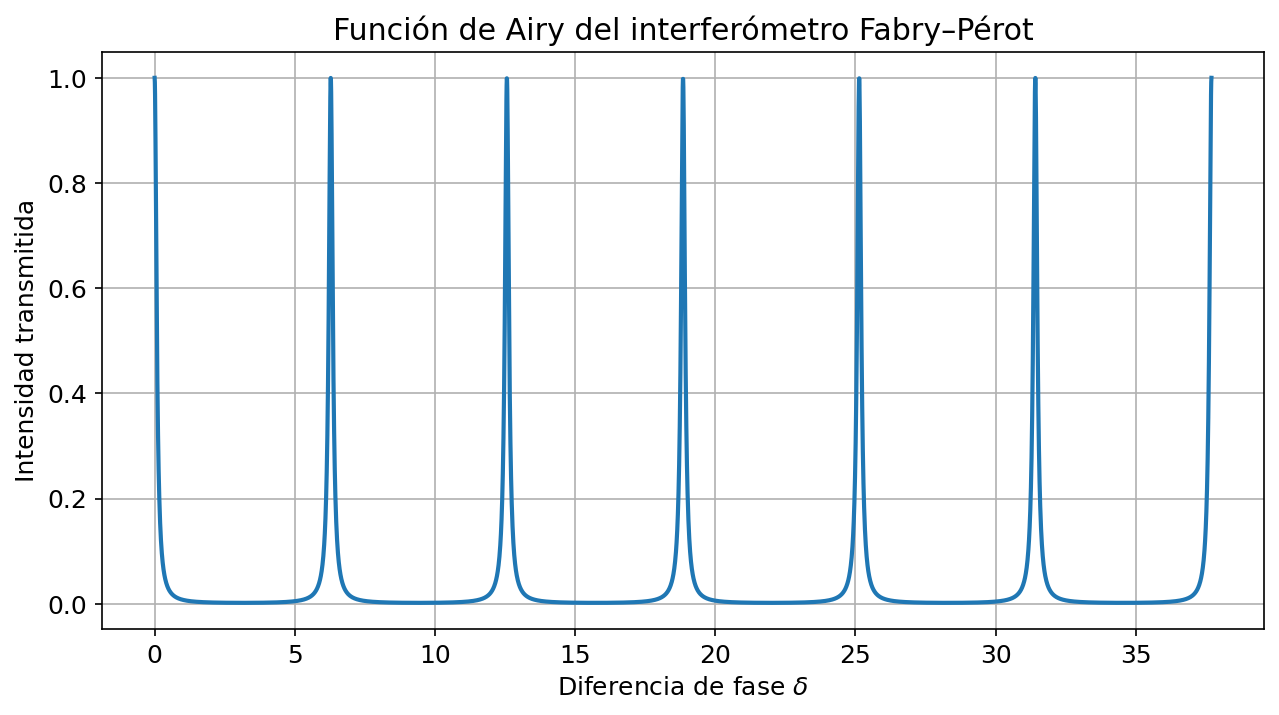

In [ ]:
R = 0.92
F = 4*R/(1-R)**2

delta = np.linspace(0, 12*np.pi, 5000)

I = 1/(1 + F*np.sin(delta/2)**2)

plt.figure(figsize=(10,5))

plt.plot(delta, I, linewidth=2)

plt.xlabel(r'Diferencia de fase $\delta$')
plt.ylabel('Intensidad transmitida')
plt.title('Función de Airy del interferómetro Fabry–Pérot')

plt.grid(True)

plt.show()

***Simulación bidimensional de los anillos de interferencia***

Se modela la geometría radial del sistema óptico y calcula el ángulo asociado a cada punto de la pantalla simulada, con lo que se calcula la diferencia de fase óptica y evalúa la función de Airy punto por punto.

*Pd. Se aplica un perfil gaussiano para representar la distribución real de intensidad del láser y un suavizado óptico que elimina discontinuidades numéricas.*



*   Cada longitud de onda produce un patrón interferencial diferente debido a que la separación angular entre resonancias depende directamente de λ. Las gráficas permiten comparar visualmente cómo cambian los anillos al variar la longitud de onda, mostrando que longitudes mayores producen menos anillos visibles y una separación más amplia entre ellos, comportamiento consistente con las predicciones teóricas del modelo Fabry–Pérot.



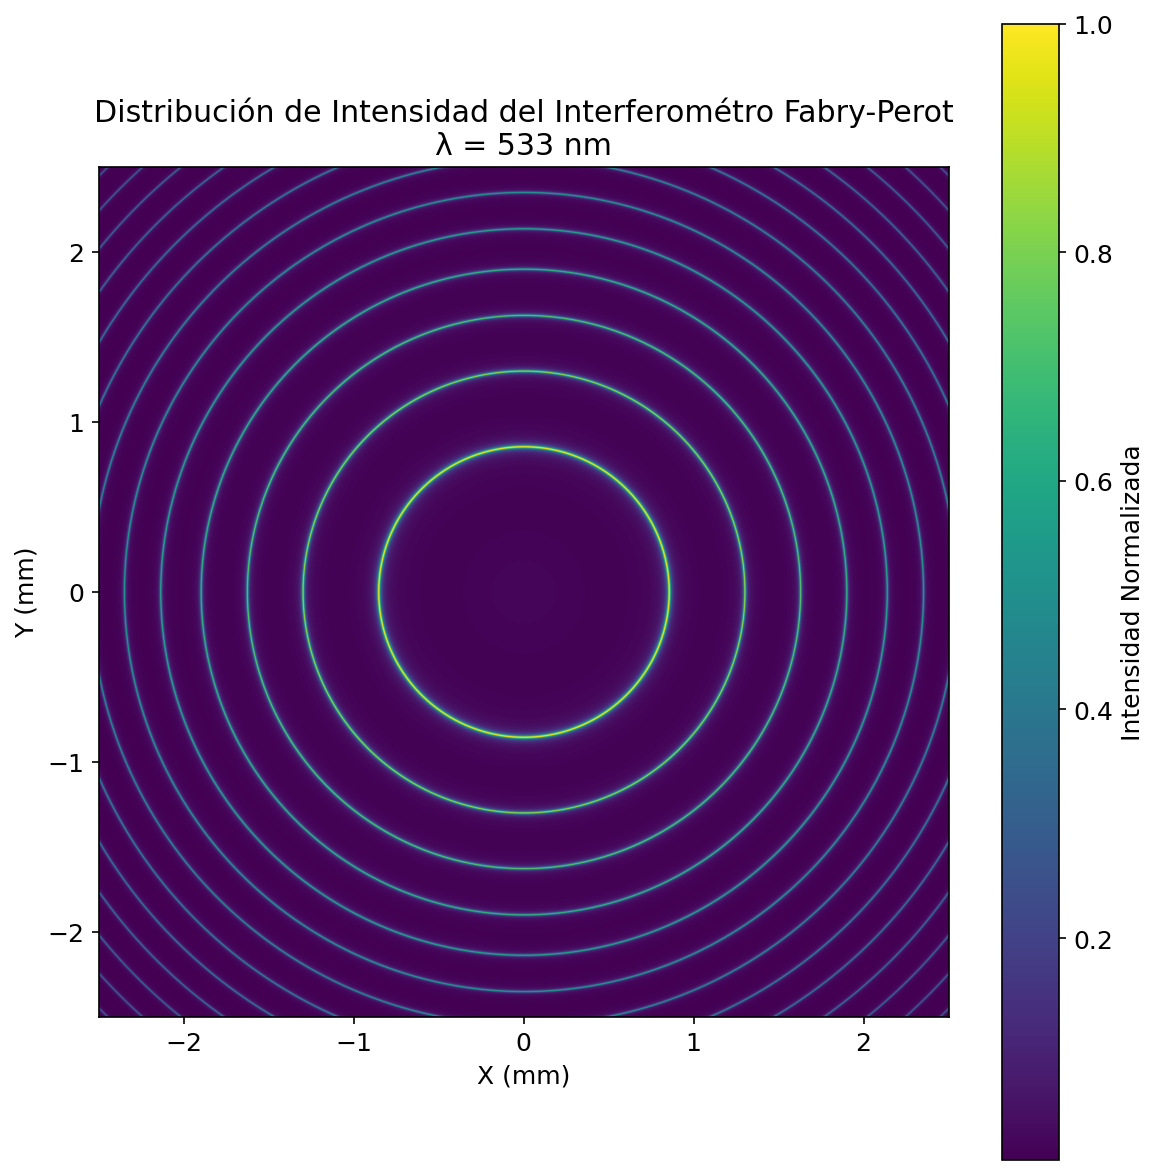

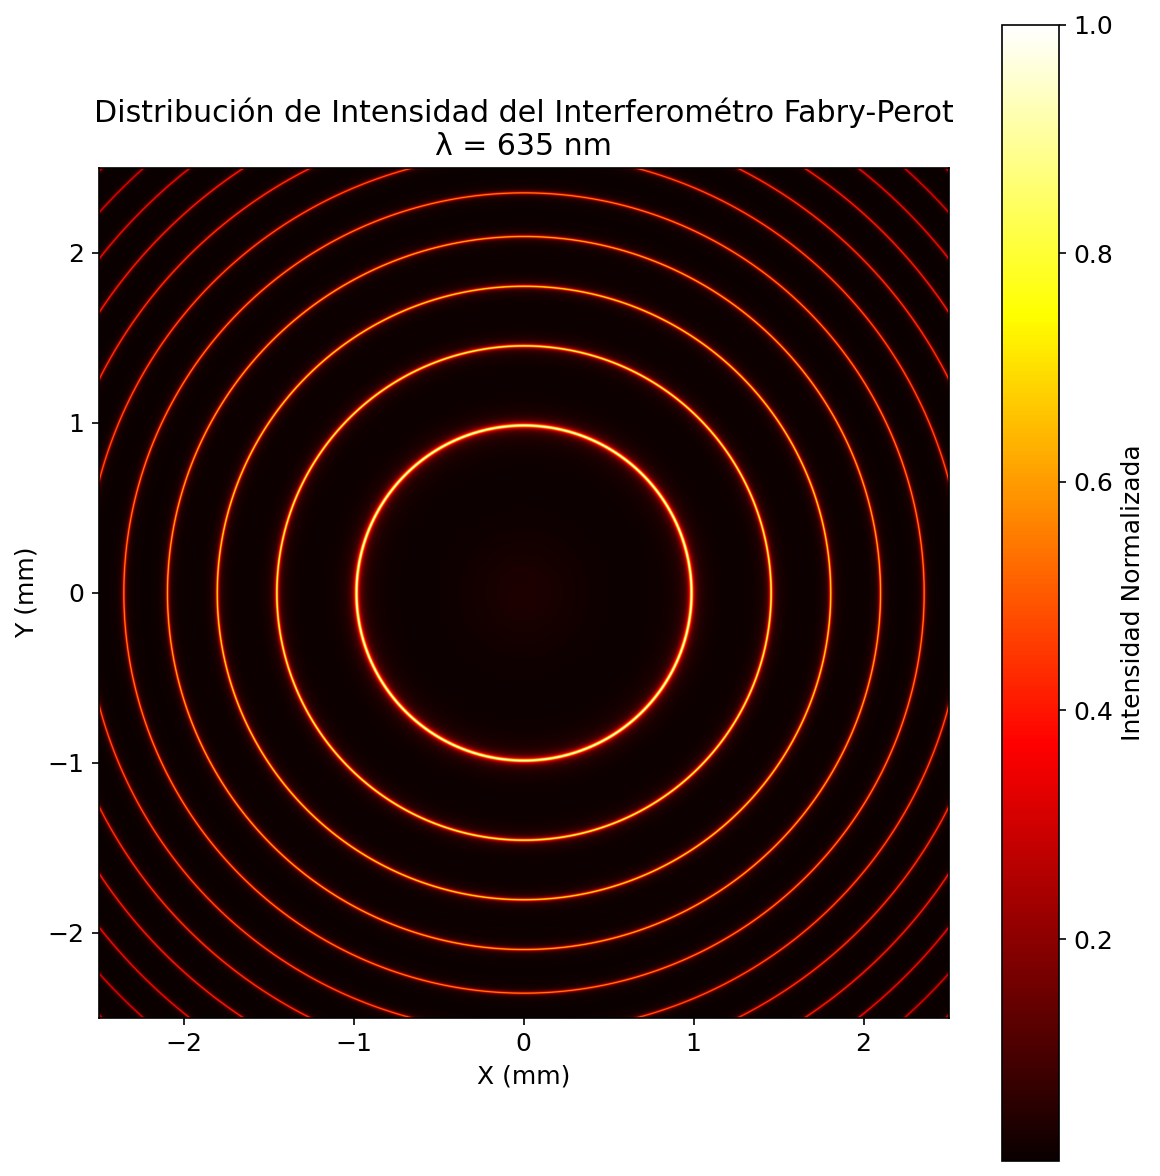

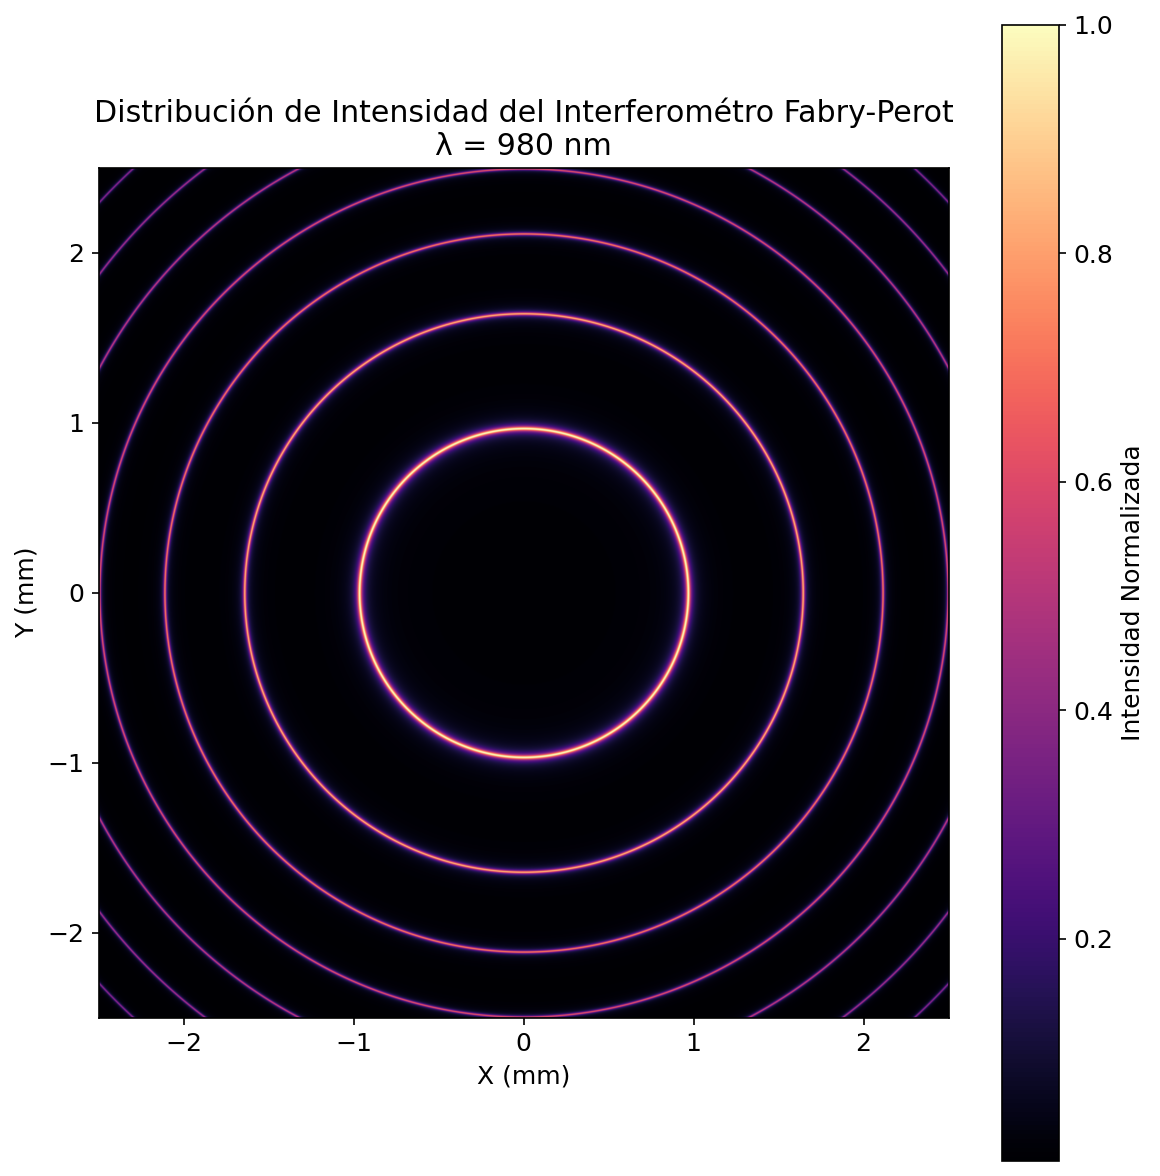

In [ ]:
def fabry_perot(wavelength_nm):

    wavelength = wavelength_nm * 1e-9
    d = 8e-3
    R = 0.94

    F = 4*R/(1-R)**2
    N = 2200
    L = 2.5e-3

    x = np.linspace(-L, L, N)
    y = np.linspace(-L, L, N)

    X, Y = np.meshgrid(x, y)
    r = np.sqrt(X**2 + Y**2)
    f = 0.12
    theta = np.arctan(r/f)
    delta = (4*np.pi*d*np.cos(theta))/wavelength
    I = 1/(1 + F*np.sin(delta/2)**2)
    beam = np.exp(-(r/(3.2e-3))**2)

    I = I * beam
    I = I**0.65

    I = gaussian_filter(I, sigma=0.9)

    I = I/np.max(I)

    return I

wavelengths = [533, 635, 980]

colormaps = {
    533: 'viridis',
    635: 'hot',
    980: 'magma'
}

for wl in wavelengths:

    pattern = fabry_perot(wl)

    plt.figure(figsize=(8,8))

    plt.imshow(
        pattern,
        cmap=colormaps[wl],
        origin='lower',
        extent=[-2.5,2.5,-2.5,2.5]
    )

    plt.xlabel('X (mm)')
    plt.ylabel('Y (mm)')

    plt.title(
        f'Distribución de Intensidad del Interferométro Fabry-Perot\n'
        f'λ = {wl} nm'
    )

    cbar = plt.colorbar()
    cbar.set_label('Intensidad Normalizada')

    plt.tight_layout()

    plt.show()

***Comparación Datos Experimentales***

introduce los datos obtenidos durante el experimento real. Se definen las vueltas del goniómetro y el número de colapsos observados para cada láser utilizado en el laboratorio. El objetivo es construir una representación cuantitativa de la respuesta experimental del interferómetro y relacionarla con las predicciones del modelo matemático.

genera una gráfica comparativa entre el número de colapsos observados y las vueltas del goniómetro para las tres longitudes de onda utilizadas. Esta visualización permite analizar cómo cambia la respuesta resonante del sistema al modificar la frecuencia de la luz incidente. La tendencia obtenida muestra que fuentes de mayor longitud de onda producen menos colapsos, lo cual coincide con las condiciones de resonancia derivadas teóricamente a partir del modelo diferencial y de la función de Airy.

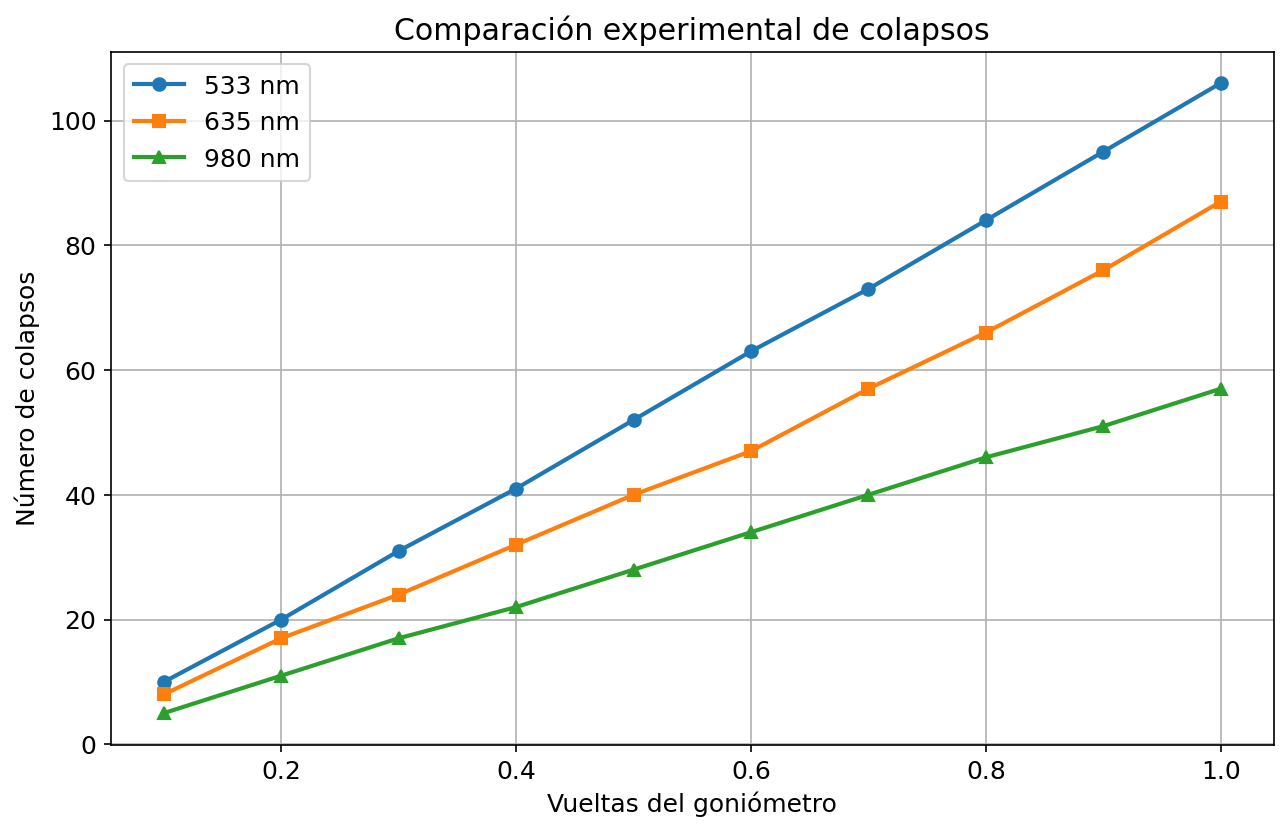

In [ ]:
giros = np.arange(0, 55, 5)

vueltas = np.arange(0.1, 1.1, 0.1)

colapsos_533 = np.array([10,20,31,41,52,63,73,84,95,106])

colapsos_635 = np.array([8,17,24,32,40,47,57,66,76,87])

colapsos_980 = np.array([5,11,17,22,28,34,40,46,51,57])

plt.figure(figsize=(10,6))

plt.plot(vueltas, colapsos_533, 'o-', linewidth=2, label='533 nm')
plt.plot(vueltas, colapsos_635, 's-', linewidth=2, label='635 nm')
plt.plot(vueltas, colapsos_980, '^-', linewidth=2, label='980 nm')

plt.xlabel('Vueltas del goniómetro')
plt.ylabel('Número de colapsos')

plt.title('Comparación experimental de colapsos')

plt.grid(True)

plt.legend()

plt.show()

***Curvas resonantes***

Se calculan curvas de intensidad transmitida en función del ángulo de incidencia para diferentes valores de longitud de onda. Estas curvas representan la selectividad espectral del resonador Fabry–Pérot y permiten observar cómo ciertas frecuencias son transmitidas con mayor intensidad que otras. La simulación reproduce el comportamiento típico de un sistema resonante y establece una conexión directa con la analogía del oscilador armónico amortiguado desarrollada en el marco teórico.

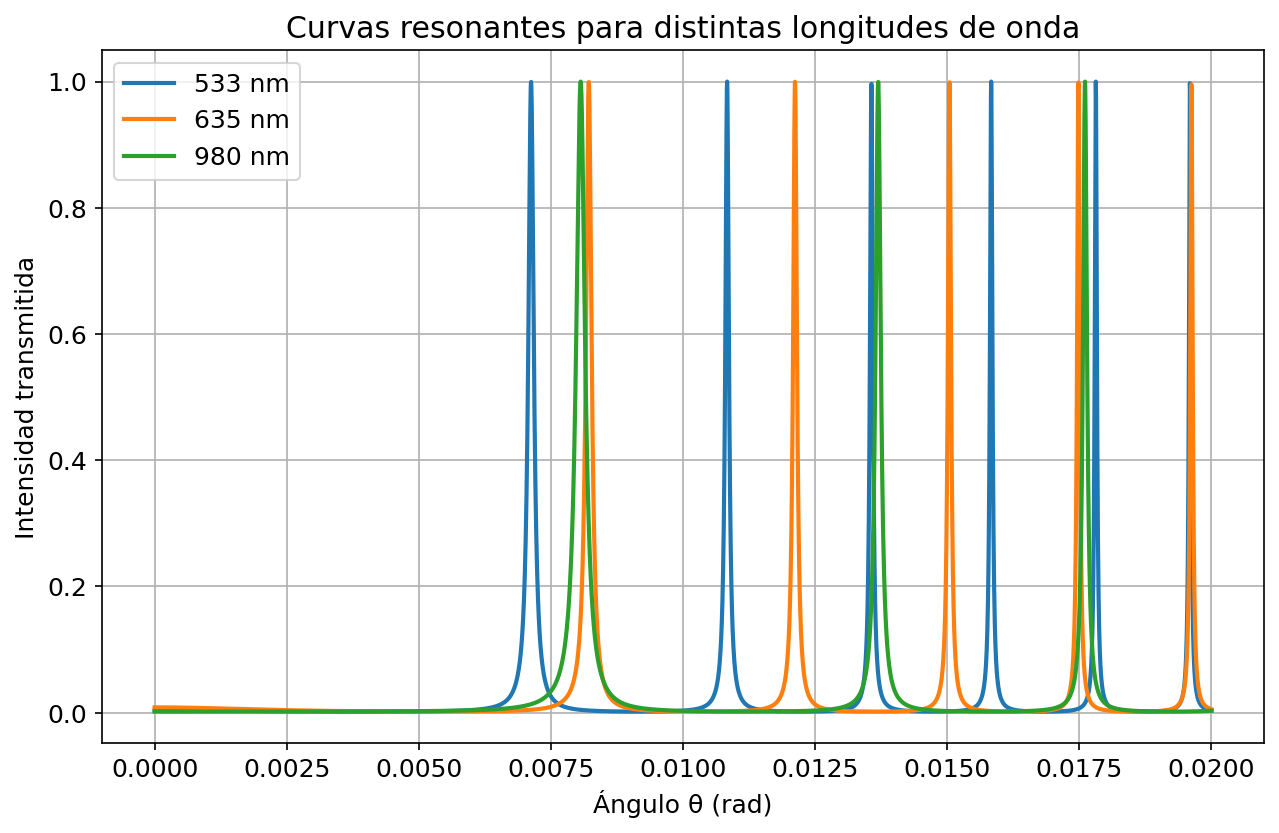

In [ ]:
plt.figure(figsize=(10,6))

for wl in wavelengths:

    wavelength = wl*1e-9

    d = 8e-3

    theta = np.linspace(0, 0.02, 5000)

    delta = (4*np.pi*d*np.cos(theta))/wavelength

    I = 1/(1 + F*np.sin(delta/2)**2)

    plt.plot(theta, I, linewidth=2, label=f'{wl} nm')

plt.xlabel('Ángulo θ (rad)')
plt.ylabel('Intensidad transmitida')

plt.title('Curvas resonantes para distintas longitudes de onda')

plt.grid(True)

plt.legend()

plt.show()

**Longitud de Ondas vs Colapsos**

Se construye una gráfica que relaciona el promedio de colapsos experimentales con la longitud de onda de cada fuente láser. Esta representación resume una de las conclusiones principales del proyecto: al aumentar la longitud de onda disminuye el número de resonancias observadas en el sistema. La gráfica permite validar experimentalmente la dependencia teórica entre fase óptica, resonancia y longitud de onda predicha por el modelo matemático desarrollado a partir de las ecuaciones de Maxwell y la teoría de interferencia múltiple.

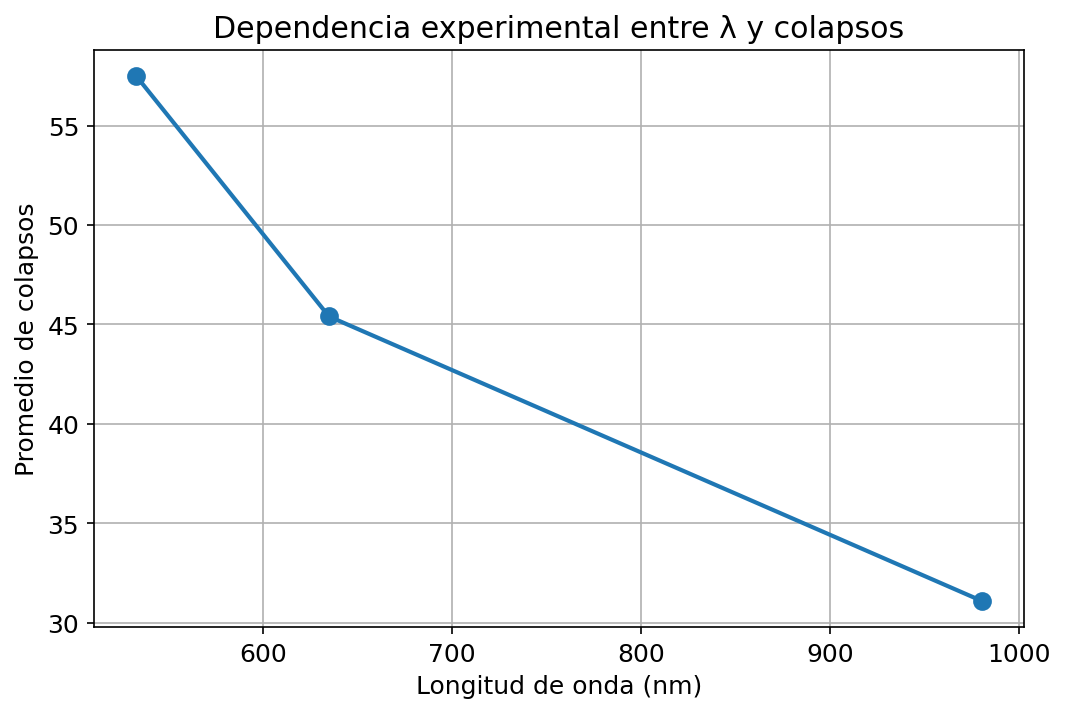

In [ ]:
lambda_vals = np.array([533,635,980])

colapsos_totales = np.array([
    np.mean(colapsos_533),
    np.mean(colapsos_635),
    np.mean(colapsos_980)
])

plt.figure(figsize=(8,5))

plt.plot(
    lambda_vals,
    colapsos_totales,
    'o-',
    linewidth=2,
    markersize=8
)

plt.xlabel('Longitud de onda (nm)')
plt.ylabel('Promedio de colapsos')

plt.title('Dependencia experimental entre λ y colapsos')

plt.grid(True)

plt.show()